In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd

# Path relative to the notebooks folder
df = pd.read_csv('../data/raw/train.csv')

# Check the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Check for missing values in the whole dataset
print("\n--- MISSING DATA SUMMARY ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

--- FIRST 5 ROWS ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- MISSING DATA SUMMARY ---
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


In [4]:
# len() gives you the 'length' or total number of rows
print(len(df))

1460


In [5]:
# (rows, columns)
print(df.shape)

(1460, 81)


In [6]:
#====================DATA CLEANING==================================
            #Dropping
# Create a list of columns to drop
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# Drop them and save to a new dataframe variable so we don't lose the original
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Original columns: {df.shape[1]}")
print(f"Columns after dropping: {df_cleaned.shape[1]}")

Original columns: 81
Columns after dropping: 77


In [7]:
           #flagging
# List of categorical columns where NaN means 'None'
none_cols = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond']

for col in none_cols:
    df_cleaned[col] = df_cleaned[col].fillna('None')

# Check if FireplaceQu still has missing values
print(f"Missing values in FireplaceQu: {df_cleaned['FireplaceQu'].isnull().sum()}")

Missing values in FireplaceQu: 0


In [8]:
        #Imputing(Filling with median)
# Fill LotFrontage with the median value of that column
median_value = df_cleaned['LotFrontage'].median()
df_cleaned['LotFrontage'] = df_cleaned['LotFrontage'].fillna(median_value)

print(f"Missing values in LotFrontage: {df_cleaned['LotFrontage'].isnull().sum()}")

Missing values in LotFrontage: 0


Note: you may need to restart the kernel to use updated packages.


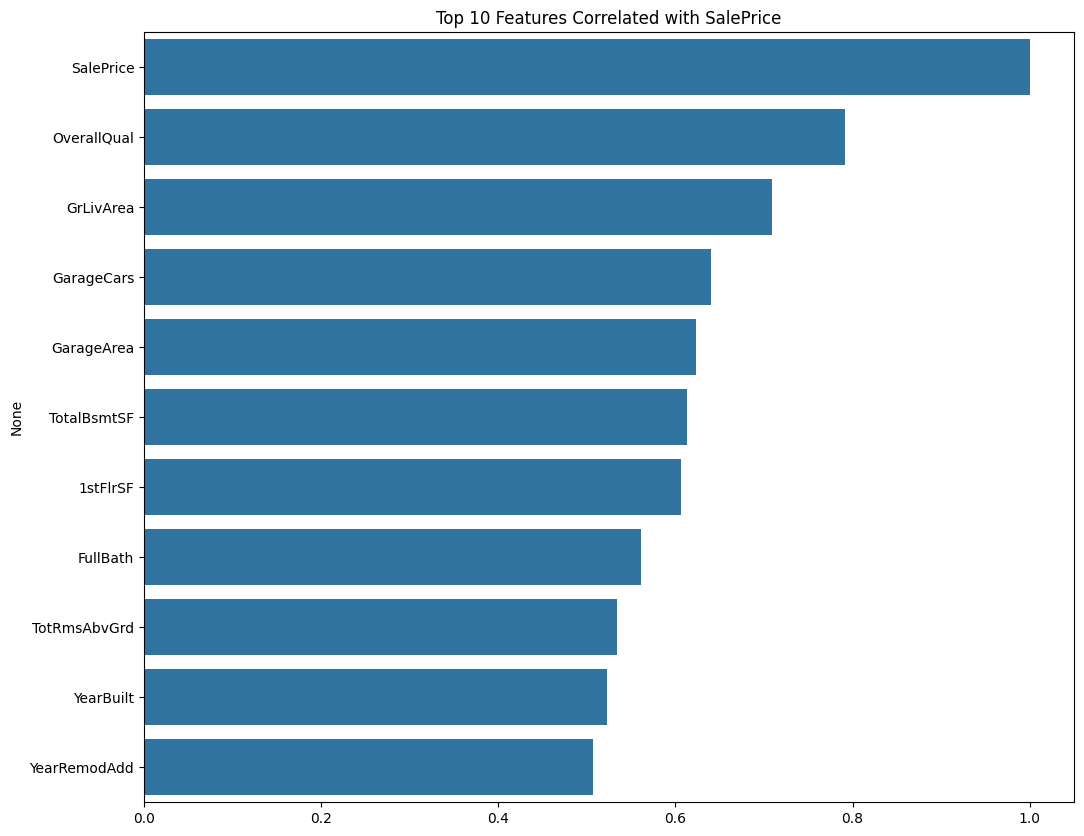

In [9]:
#============HEAT MAP TO CHECK THE CORELATION WITH THE SALE_PRICE FEATURE============
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# We only look at numeric columns for correlation
numeric_df = df_cleaned.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Plot the top 10 features most correlated with SalePrice
top_corr_features = correlation_matrix['SalePrice'].sort_values(ascending=False).head(11)
sns.barplot(x=top_corr_features.values, y=top_corr_features.index)
plt.title('Top 10 Features Correlated with SalePrice')
plt.show()

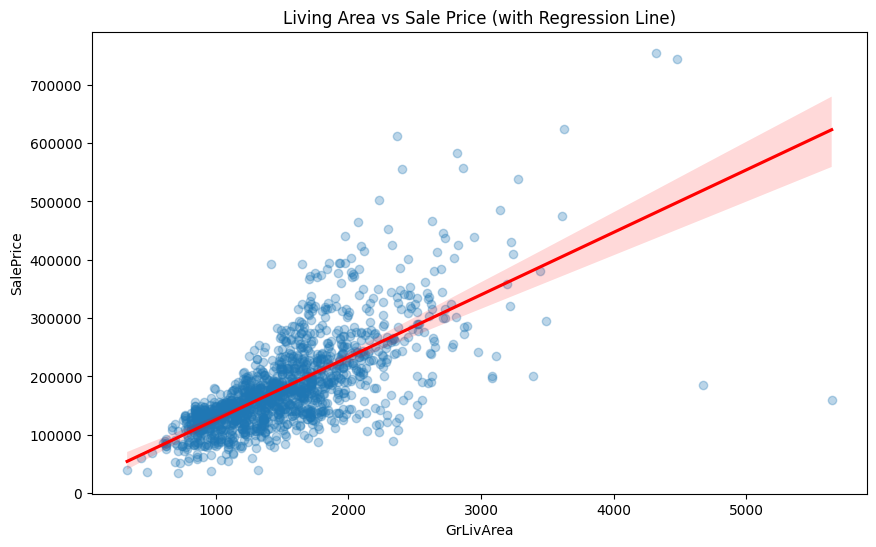

In [10]:
# ===========grlivarea is the best feature against sales_price===========
#===========We are seeing how it scales with sales price===============
plt.figure(figsize=(10, 6))
sns.regplot(x=df_cleaned['GrLivArea'], y=df_cleaned['SalePrice'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Living Area vs Sale Price (with Regression Line)')
plt.show()

In [11]:
#handling outliers
# Create a final version of the data without the extreme outliers
# We are filtering the 'GrLivArea' to stay under 4000 square feet
df_final = df_cleaned[df_cleaned['GrLivArea'] < 4000]

print(f"Rows before: {len(df_cleaned)}")
print(f"Rows after: {len(df_final)}")

Rows before: 1460
Rows after: 1456


In [12]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
#===============TRaining and Testing data============================
from sklearn.model_selection import train_test_split

# 1. Choose your "Predictor" (X) and your "Target" (y)
X = df_final[['GrLivArea']] # Remember the double brackets for 2D!
y = df_final['SalePrice']

# 2. Split into Training (80%) and Testing (20%)
# 'random_state=42' ensures we get the same "shuffle" every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Houses: {len(df_final)}")
print(f"Houses for Training: {len(X_train)}")
print(f"Houses for Testing: {len(X_test)}")

Total Houses: 1456
Houses for Training: 1164
Houses for Testing: 292


In [14]:
# Calculate the average (mean) of our training data
avg_area = X_train['GrLivArea'].mean()
avg_price = y_train.mean()

print(f"The average house in our training set is {avg_area:.2f} sq ft.")
print(f"The average price is ${avg_price:.2f}.")

The average house in our training set is 1510.07 sq ft.
The average price is $181336.76.


In [15]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
# We'll use the raw values for simplicity
x = X_train['GrLivArea'].values
y = y_train.values

# Calculate the difference from the mean for each house
x_diff = x - avg_area
y_diff = y - avg_price

# Top Part: Multiplying the differences and summing them
numerator = np.sum(x_diff * y_diff)

# Bottom Part: Squaring the size differences and summing them
denominator = np.sum(x_diff**2)

# Final Slope
m_final = numerator / denominator

print(f"Top Part (Co-movement): {numerator:.2f}")
print(f"Bottom Part (Size Spread): {denominator:.2f}")
print(f"Final Slope (m): {m_final:.2f}")

Top Part (Co-movement): 32439624365.54
Bottom Part (Size Spread): 279765107.65
Final Slope (m): 115.95


In [17]:
# Calculate the intercept (c)
c_final = avg_price - (m_final * avg_area)

print(f"Base Price (Intercept c): ${c_final:.2f}")
print(f"---")
print(f"YOUR MANUAL FORMULA: SalePrice = ({m_final:.2f} * Area) + {c_final:.2f}")

Base Price (Intercept c): $6239.05
---
YOUR MANUAL FORMULA: SalePrice = (115.95 * Area) + 6239.05


In [18]:
# 1. Predict using the math we built (y = mx + c)
predictions = (m_final * x) + c_final

# 2. Calculate the 'Difference' for every house
# We use 'abs' because a -$10k error is just as bad as a +$10k error
all_errors = np.abs(y - predictions)

# 3. Find the average of all those errors
final_mae = np.mean(all_errors)

print(f"--- THE FINAL VERDICT ---")
print(f"Our model's formula: Price = ({m_final:.2f} * Area) + {c_final:.2f}")
print(f"Average Error (MAE): ${final_mae:,.2f}")

--- THE FINAL VERDICT ---
Our model's formula: Price = (115.95 * Area) + 6239.05
Average Error (MAE): $36,776.40


In [19]:
# 1. Sum of Squared Errors for YOUR model (SSR)
# We square them so big misses count more
ss_res = np.sum((y - predictions)**2)

# 2. Total Sum of Squares (SST) 
# This is the error if we just guessed the Average Price for every house
ss_tot = np.sum((y - avg_price)**2)

# 3. The R-Squared Formula
r2_score = 1 - (ss_res / ss_tot)

print(f"R-Squared Score: {r2_score:.4f}")
print(f"In plain English: Your model explains {r2_score*100:.2f}% of the price variation.")

R-Squared Score: 0.5360
In plain English: Your model explains 53.60% of the price variation.


In [22]:
# 1. Define our new team of features (using the top ones from your correlation chart)
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath']

# 2. Prepare the data using your variable name 'df_final'
X_multi = df_final[features]
y_multi = df_final['SalePrice']

# 3. Train the multiple linear regression model
from sklearn.linear_model import LinearRegression
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

# 4. Check the new Score
new_r2 = multi_model.score(X_multi, y_multi)

print(f"Old R-Squared (Area only): 0.5360")
print(f"New R-Squared (Top 5 features): {new_r2:.4f}")

Old R-Squared (Area only): 0.5360
New R-Squared (Top 5 features): 0.8027


In [23]:
# Create a small table to show the weights
weights = pd.DataFrame(multi_model.coef_, features, columns=['Value per Unit'])

print("--- HOW YOUR MODEL SEES THE WORLD ---")
print(weights)
print(f"\nBase Price (Intercept): ${multi_model.intercept_:,.2f}")

--- HOW YOUR MODEL SEES THE WORLD ---
             Value per Unit
OverallQual    22105.287914
GrLivArea         51.135632
GarageCars     15912.872826
TotalBsmtSF       44.827203
FullBath       -2112.691961

Base Price (Intercept): $-103,350.43


In [24]:
#=========testing on new data===============
# 1. Define our "Dream House"
# IMPORTANT: The numbers MUST be in the exact same order as our 'features' list:
# ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath']
dream_house = [[8, 2000, 2, 800, 2]]

# 2. Ask the model to guess the price
predicted_price = multi_model.predict(dream_house)

print(f"The model's official appraisal for this house is: ${predicted_price[0]:,.2f}")

The model's official appraisal for this house is: $239,225.26


/workspaces/Housing-price-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
# Save the cleaned data to your processed folder
df_final.to_csv('../data/processed/cleaned_train.csv', index=False)
print("Cleaned data saved to data/processed/!")

Cleaned data saved to data/processed/!
